<a href="https://colab.research.google.com/github/reinanbr/colab_notebooks/blob/main/mapping.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!apt install python3-rtree --quiet
!pip install osmnx
!pip install geopandas
!pip install matplotlib
!pip install descartes

In [ ]:
from descartes import PolygonPatch
import geopandas as gpd
from shapely.geometry import Point, LineString, Polygon
import networkx as nx
import osmnx as ox
import numpy as np
import multiprocessing as mp
import matplotlib.pyplot as plt
%matplotlib inline

### examples

In [ ]:
place = 'casa nova, bahia'

casa_nova_g = ox.graph_from_place(place, truncate_by_edge=True, retain_all=True)


In [ ]:
tags = {"building": True}

casa_nova_fp = ox.geometries_from_place(place,tags)

proj_gdf = ox.project_gdf(casa_nova_fp)


/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)
<ipython-input-30-b8eb00401c82>:3: UserWarning: The `geometries` module and `geometries_from_X` functions have been renamed the `features` module and `features_from_X` functions. Use these instead. The `geometries` module and function names are deprecated and will be removed in a future release.
  casa_nova_fp = ox.geometries_from_place(place,tags)


/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


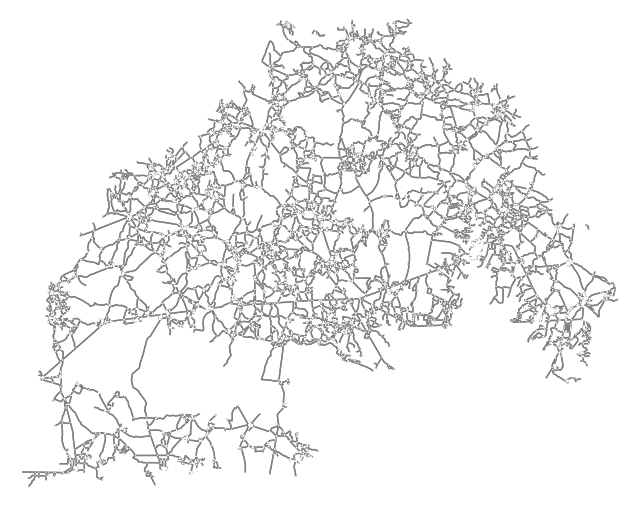

In [ ]:
bgcolor = '#343434'
edge_color = '#FFB0E2'
bldg_color = '#F4FF6E'




fig, ax = ox.plot_graph(casa_nova_g,bgcolor='w', node_size=.6, edge_color='gray')


In [ ]:
ox.config(log_console=True, use_cache=True)

place = 'new york, NEW YORK'

bgcolor = '#343434'
edge_color = '#FFB0E2'
bldg_color = '#F4FF6E'



fp = ox.geometries_from_place(place, tags={'building':True})
G = ox.graph_from_place(place, network_type='drive', truncate_by_edge=True, retain_all=True)

fig, ax = ox.plot_graph(G, bgcolor=bgcolor, node_size=0, edge_color=edge_color, show=False)
fig, ax = ox.plot_footprints(fp, ax=ax, color=bldg_color, save=True)

<ipython-input-22-fe759f680239>:1: UserWarning: The `utils.config` function is deprecated and will be removed in a future release. Instead, use the `settings` module directly to configure a global setting's value. For example, `ox.settings.log_console=True`.
  ox.config(log_console=True, use_cache=True)
<ipython-input-22-fe759f680239>:11: UserWarning: The `geometries` module and `geometries_from_X` functions have been renamed the `features` module and `features_from_X` functions. Use these instead. The `geometries` module and function names are deprecated and will be removed in a future release.
  fp = ox.geometries_from_place(place, tags={'building':True})


KeyboardInterrupt: ignored

<ipython-input-63-0cc69742074f>:3: UserWarning: The `utils.config` function is deprecated and will be removed in a future release. Instead, use the `settings` module directly to configure a global setting's value. For example, `ox.settings.log_console=True`.
  ox.config(log_console=True, use_cache=True)
<ipython-input-63-0cc69742074f>:20: UserWarning: The `geometries` module and `geometries_from_X` functions have been renamed the `features` module and `features_from_X` functions. Use these instead. The `geometries` module and function names are deprecated and will be removed in a future release.
  fp = ox.geometries_from_point(point, tags={'building':True}, dist=dist)


['__add__', '__class__', '__class_getitem__', '__contains__', '__delattr__', '__dir__', '__doc__', '__eq__', '__format__', '__ge__', '__getattribute__', '__getitem__', '__getnewargs__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__iter__', '__le__', '__len__', '__lt__', '__mul__', '__ne__', '__new__', '__reduce__', '__reduce_ex__', '__repr__', '__rmul__', '__setattr__', '__sizeof__', '__str__', '__subclasshook__', 'count', 'index']


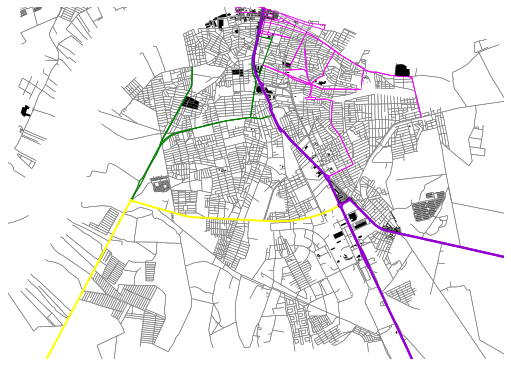

In [ ]:
# JUAZEIRO BA

ox.config(log_console=True, use_cache=True)

place = 'Juazeiro, BA'
bgcolor = 'w'
edge_color = 'gray'
bldg_color = 'black'
point = (-9.429331, -40.506912)
latitude = point[0]
longitude = point[1]
add = .05
north = latitude +add-0.03
south = latitude -add
east = longitude +add
west = longitude -add
dist = 5200

bbox = ox.utils_geo.bbox_from_point(point, dist=dist)
fp = ox.geometries_from_point(point, tags={'building':True}, dist=dist)
G = ox.graph_from_point(point, network_type='all', dist=dist, truncate_by_edge=True, retain_all=True)


G_river = ox.graph_from_place(place,simplify=True,retain_all=False,truncate_by_edge=False,custom_filter='["waterway"]')
G_higway = ox.graph_from_place(place,simplify=True,retain_all=False,truncate_by_edge=False,custom_filter='["highway"~"way"]')

G_higpri = ox.graph_from_place(place,custom_filter='["highway"~"primary"]')
G_higsec = ox.graph_from_place(place,custom_filter='["highway"~"secondary"]')
G_waytrunk = ox.graph_from_place(place,custom_filter='["highway"~"trunk"]')
G_terti = ox.graph_from_place(place,custom_filter='["highway"~"tertiary"]')
G_rail = ox.graph_from_place(place,custom_filter='["railway"]')

G_higpath = ox.graph_from_place(place,custom_filter='["highway"~"residential"]')


fig, ax_ = ox.plot_graph(G, bgcolor=bgcolor, node_size=0,edge_linewidth=.5, edge_color=edge_color,edge_alpha=1, show=False)

# fig,ax = ox.plot_graph(G_higway,bgcolor=bgcolor,ax=ax_,edge_linewidth=.5, node_size=0, edge_color='red', show=False)
fig,ax = ox.plot_graph(G_higpri,bgcolor=bgcolor,ax=ax_,edge_linewidth=1.5, node_size=0, edge_color='yellow', show=False)
fig,ax = ox.plot_graph(G_higsec,bgcolor=bgcolor,ax=ax_,edge_linewidth=1., node_size=0, edge_color='green', show=False)
fig,ax = ox.plot_graph(G_waytrunk,bgcolor=bgcolor,ax=ax_,edge_linewidth=2, node_size=0, edge_color='darkviolet', show=False)
fig,ax = ox.plot_graph(G_terti,bgcolor=bgcolor,ax=ax_,edge_linewidth=.7, node_size=0, edge_color='magenta', show=False)

#fig,ax = ox.plot_graph(G_rail,bgcolor=bgcolor,ax=ax_,edge_linewidth=.5, node_size=0, edge_color='darkred', show=False)

fig,ax = ox.plot_graph(G_river,bgcolor=bgcolor,ax=ax_,edge_linewidth=.6, node_size=1, edge_color='blue', show=False)

print(dir(bbox))
fig, ax = ox.plot_footprints(fp, ax=ax_, bbox = (north, south, east, west), color=bldg_color, save=True)

<ipython-input-69-1eccdad269a8>:3: UserWarning: The `utils.config` function is deprecated and will be removed in a future release. Instead, use the `settings` module directly to configure a global setting's value. For example, `ox.settings.log_console=True`.
  ox.config(log_console=True, use_cache=True)
<ipython-input-69-1eccdad269a8>:20: UserWarning: The `geometries` module and `geometries_from_X` functions have been renamed the `features` module and `features_from_X` functions. Use these instead. The `geometries` module and function names are deprecated and will be removed in a future release.
  fp = ox.geometries_from_point(point, tags={'building':True}, dist=dist)


['__add__', '__class__', '__class_getitem__', '__contains__', '__delattr__', '__dir__', '__doc__', '__eq__', '__format__', '__ge__', '__getattribute__', '__getitem__', '__getnewargs__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__iter__', '__le__', '__len__', '__lt__', '__mul__', '__ne__', '__new__', '__reduce__', '__reduce_ex__', '__repr__', '__rmul__', '__setattr__', '__sizeof__', '__str__', '__subclasshook__', 'count', 'index']


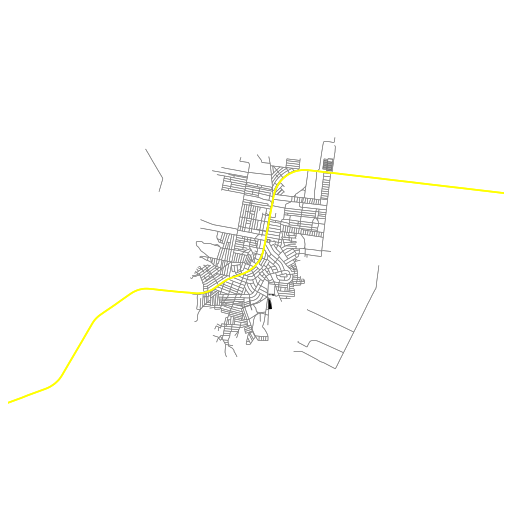

In [ ]:
# CASA NOVA, BA

ox.config(log_console=True, use_cache=True)

place = 'Casa nova, BA'
bgcolor = 'w'
edge_color = 'gray'
bldg_color = 'black'
point = (-9.173126, -40.975127)
latitude = point[0]
longitude = point[1]
add = .05
north = latitude +add
south = latitude -add
east = longitude +add
west = longitude -add
dist = 2200

bbox = ox.utils_geo.bbox_from_point(point, dist=dist)
fp = ox.geometries_from_point(point, tags={'building':True}, dist=dist)
G = ox.graph_from_point(point, network_type='all', dist=dist, truncate_by_edge=True, retain_all=True)


G_river = ox.graph_from_place(place,simplify=True,retain_all=False,truncate_by_edge=False,custom_filter='["waterway"]')

G_higpri = ox.graph_from_place(place,custom_filter='["highway"~"primary"]')
#G_higsec = ox.graph_from_place(place,custom_filter='["highway"~"secondary"]')
#G_waytrunk = ox.graph_from_place(place,custom_filter='["highway"~"trunk"]')
#G_terti = ox.graph_from_place(place,custom_filter='["highway"~"tertiary"]')
#G_rail = ox.graph_from_place(place,custom_filter='["railway"]')

G_higpath = ox.graph_from_place(place,custom_filter='["highway"~"residential"]')


fig, ax_ = ox.plot_graph(G, bgcolor=bgcolor, node_size=0,edge_linewidth=.5, edge_color=edge_color,edge_alpha=1, show=False)

# fig,ax = ox.plot_graph(G_higway,bgcolor=bgcolor,ax=ax_,edge_linewidth=.5, node_size=0, edge_color='red', show=False)
fig,ax = ox.plot_graph(G_higpri,bgcolor=bgcolor,ax=ax_,edge_linewidth=1.5, node_size=0, edge_color='yellow', show=False)
#fig,ax = ox.plot_graph(G_higsec,bgcolor=bgcolor,ax=ax_,edge_linewidth=1., node_size=0, edge_color='green', show=False)
#fig,ax = ox.plot_graph(G_waytrunk,bgcolor=bgcolor,ax=ax_,edge_linewidth=2, node_size=0, edge_color='darkviolet', show=False)
#fig,ax = ox.plot_graph(G_terti,bgcolor=bgcolor,ax=ax_,edge_linewidth=.7, node_size=0, edge_color='magenta', show=False)

#fig,ax = ox.plot_graph(G_rail,bgcolor=bgcolor,ax=ax_,edge_linewidth=.5, node_size=0, edge_color='darkred', show=False)

fig,ax = ox.plot_graph(G_river,bgcolor=bgcolor,ax=ax_,edge_linewidth=.6, node_size=1, edge_color='blue', show=False)

print(dir(bbox))
fig, ax = ox.plot_footprints(fp, ax=ax_, bbox = (north, south, east, west), color=bldg_color, save=True)

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


<Axes: >

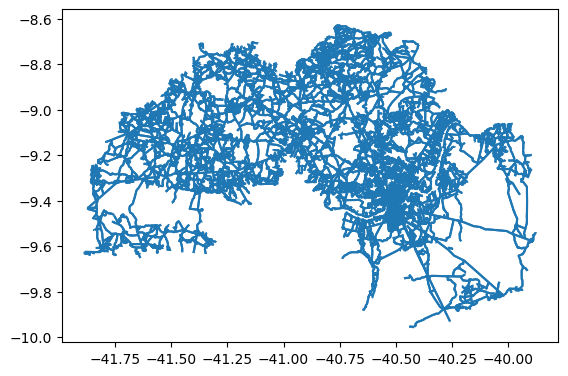

In [ ]:
place_name = ['casa nova, BA','petrolina, PE','juazeiro,BA']
G = ox.graph_from_place(place_name)
nodes, edges = ox.graph_to_gdfs(G)
edges.plot()

In [ ]:
area = ox.geocode_to_gdf(place_name)

/usr/local/lib/python3.10/dist-packages/geopandas/plotting.py:658: UserWarning: Only specify one of 'column' or 'color'. Using 'color'.
  warnings.warn(


(-42.0, -39.5, -10.0, -8.6)

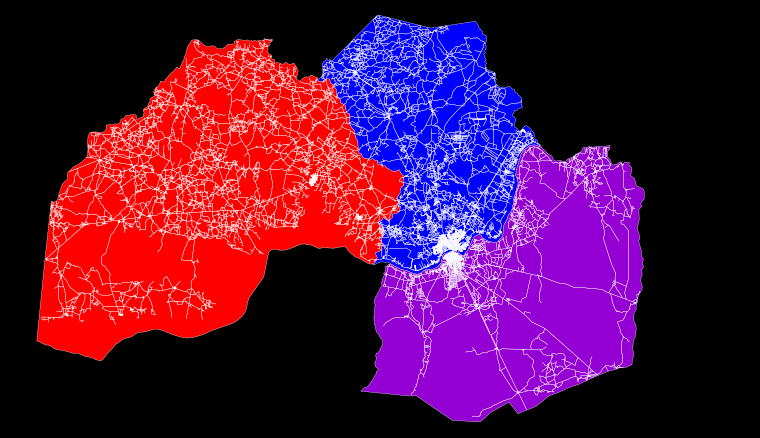

In [ ]:
plt.style.use('dark_background')


fig, ax = plt.subplots(figsize=(12,8))

# Plot the footprint
area.plot(ax=ax,column='importance',color=['red','blue','darkviolet'],linewidth=.3)

# Plot street edges
edges.plot(ax=ax, linewidth=.3, edgecolor='w')
plt.axis('off')

In [ ]:
ox.folium.plot_graph_folium(G)

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)
<ipython-input-29-2acad98f8e44>:1: UserWarning: The `folium` module has been deprecated and will be removed in a future release. You can generate and explore interactive web maps of graph nodes, edges, and/or routes automatically using GeoPandas.GeoDataFrame.explore instead, for example like: `ox.graph_to_gdfs(G, nodes=False).explore()`. See the OSMnx examples gallery for complete details and demonstrations.
  ox.folium.plot_graph_folium(G)


In [ ]:
from google.colab import files
files.download('plot_drive.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:

import osmnx as ox

place = ["Berlin, Germany"]
G = ox.graph_from_place(place, retain_all=True, simplify = True, network_type='all')

import osmnx as ox
center_point = (40.4168, -3.7038)
u = []
v = []
key = []
data = []
for uu, vv, kkey, ddata in G.edges(keys=True, data=True):
    u.append(uu)
    v.append(vv)
    key.append(kkey)
    data.append(ddata)


# Lists to store colors and widths
roadColors = []
roadWidths = []

for item in data:
    if "length" in item.keys():
        if item["length"] <= 100:
            linewidth = 0.10
            color = "#a6a6a6"

        elif item["length"] > 100 and item["length"] <= 200:
            linewidth = 0.15
            color = "#676767"

        elif item["length"] > 200 and item["length"] <= 400:
            linewidth = 0.25
            color = "#454545"

        elif item["length"] > 400 and item["length"] <= 800:
            color = "#bdbdbd"
            linewidth = 0.35
        else:
            color = "#d5d5d5"
            linewidth = 0.45

        if "primary" in item["highway"]:
            linewidth = 0.5
            color = "#ffff"
    else:
        color = "#a6a6a6"
        linewidth = 0.10

    roadColors.append(color)
    roadWidths.append(linewidth)


for item in data:
    if "footway" in item["highway"]:
        color = "#ededed"
        linewidth = 0.25
    else:
        color = "#a6a6a6"
        linewidth = 0.5

    roadWidths.append(linewidth)


#Center of the map
latitude = 40.4168
longitude = -3.7038

#Limit borders
north = latitude + 0.15
south = latitude - 0.15
east = longitude + 0.15
west = longitude - 0.15

bgcolor = "#061529"

fig, ax_ = ox.plot_graph(G, node_size=0, bbox = (north, south, east, west),
                        dpi = 300,bgcolor = bgcolor,
                        save = False, edge_color=roadColors,
                        edge_linewidth=roadWidths, edge_alpha=1)



# rivers

center_point = (40.4168, -3.7038)

G1 = ox.graph_from_point(center_point, dist=15000, dist_type='bbox', network_type='all',
                         simplify=True, retain_all=True, truncate_by_edge=False,
                         clean_periphery=False, custom_filter='["natural"~"water"]')

G2 = ox.graph_from_point(center_point, dist=15000, dist_type='bbox', network_type='all',
                         simplify=True, retain_all=True, truncate_by_edge=False,
                         clean_periphery=False, custom_filter='["waterway"~"river"]')

Gwater = nx.compose(G1, G2)

u = []
v = []
key = []
data = []
for uu, vv, kkey, ddata in Gwater.edges(keys=True, data=True):
    u.append(uu)
    v.append(vv)
    key.append(kkey)
    data.append(ddata)


# List to store colors
roadColors = []
roadWidths = []

# #72b1b1
# #5dc1b9
for item in data:
    if "name" in item.keys():
        if item["length"] > 400:
            color = "#72b1b1"
            linewidth = 2
        else:
            color = "#72b1b1"
            linewidth = 0.5
    else:
        color = "#72b1b1"
        linewidth = 0.5

    roadColors.append(color)
    roadWidths.append(linewidth)


fig, ax = ox.plot_graph(Gwater,ax=ax_, node_size=0,figsize=(27, 40),
                        dpi = 300, save = False, edge_color=roadColors,
                        edge_linewidth=roadWidths, edge_alpha=1)





# fig.tight_layout(pad=0)
# fig.savefig("madrid.png", dpi=300, bbox_inches='tight', format="png",
#             facecolor=fig.get_facecolor(), transparent=False)

### mapping


links for help:

https://geoffboeing.com/2016/11/osmnx-python-street-networks/

https://stackoverflow.com/questions/64186657/why-are-osmnx-footprints-not-filling-up-the-entire-image

https://github.com/reinanbr/osmnx_work/blob/main/nx/Untitled.ipynb

https://twitter.com/puntofisso/status/1213138287499644928/photo/1

https://stackoverflow.com/questions/47784074/trying-to-plot-two-or-more-infrastructures-in-the-same-figure-using-osmnx

https://stackoverflow.com/questions/62835420/retrieve-post-covid-pop-up-cycleways-with-openstreetmap-and-osmnx/62883614#62883614

https://stackoverflow.com/questions/62699216/osmnx-how-to-provide-more-complex-feature-into-the-custom-filter-parameter/62720802#62720802

https://stackoverflow.com/questions/62835420/retrieve-post-covid-pop-up-cycleways-with-openstreetmap-and-osmnx/62883614#62883614

https://stackoverflow.com/questions/61881345/how-to-import-multiple-infrastructure-type-in-osmnx/61897000#61897000

https://stackoverflow.com/questions/47784074/trying-to-plot-two-or-more-infrastructures-in-the-same-figure-using-osmnx/62239377#62239377

https://github.com/gboeing/osmnx-examples/blob/main/notebooks/08-custom-filters-infrastructure.ipynb

https://osmnx.readthedocs.io/en/stable/internals-reference.html

In [ ]:
ox.folium.plot_graph_folium(casa_nova_g,edge_size=.5)

<ipython-input-37-561f197d488c>:1: UserWarning: The `folium` module has been deprecated and will be removed in a future release. You can generate and explore interactive web maps of graph nodes, edges, and/or routes automatically using GeoPandas.GeoDataFrame.explore instead, for example like: `ox.graph_to_gdfs(G, nodes=False).explore()`. See the OSMnx examples gallery for complete details and demonstrations.
  ox.folium.plot_graph_folium(casa_nova_g,edge_size=.5)
